In [1]:
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from exact_solutions import GreenFunctionModes, Mode
from Trefft_tools import  TrefftzSpace, TrefftzFunction, Assemble_blockMatrix, AssembleMatrix, AssembleGreenRHS, AssembleRHS

import numpy as np
from scipy.sparse.linalg import spsolve as solve


from domains import Waveguide, ScattererShape, ScattererType

working on refinement: N=3
h_max=np.float64(0.4580471101557189)
Initial refinement:
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=4
h_max=np.float64(0.36199298260050544)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=5
h_max=np.float64(0.28998965946483024)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=6
h_max=np.float64(0.24691193897502972)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=7
h_max=np.float64(0.2052507504617864)
N_theta=3...


KeyboardInterrupt: 

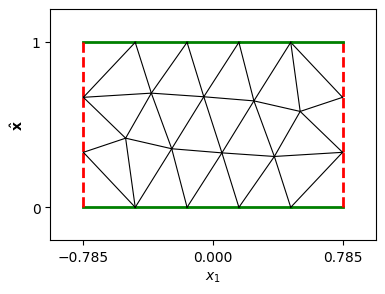

In [2]:
refinements = range(3,10,1)
N_ths = [3,5,7,9,11,13,15]


N_ref = len(refinements)
N_N_th = len(N_ths)

hs = np.zeros((N_ref), dtype=np.float64)
Hs = np.zeros((N_ref), dtype=np.float64)

conds = np.zeros((N_ref,N_N_th), dtype=np.float64)
errors = np.zeros((N_ref,N_N_th), dtype=np.float64)

factor = 8/8

kappa_e = factor*8.
lambda_e = 2*np.pi/kappa_e
R = factor*lambda_e
H = 1.


c = (0,0.6*H)



Ny = 100
Nx = int(R/H*Ny)

x = np.linspace(-R,R,Nx)
y = np.linspace(0,H,Ny)
X, Y = np.meshgrid(x,y)

t = 3
u_exact = np.reshape( Mode( kappa_e, H, np.stack([X.ravel(),Y.ravel()], axis=1), t=t), (Ny,Nx))


for (i,N) in enumerate(refinements):
    print(f"working on refinement: {N=}")
    h = H/(N)
    hs[i] = h
   
    Domain = Waveguide(R=R,H=H) 
    Domain.generate_mesh(h_max=h)

    side_ls = np.array([E.l for E in Domain.Edges])
    h_max = np.max(side_ls)
    Hs[i] = h_max
    print(f'{h_max=}')

    if i == 0:
        print('Initial refinement:')
        Domain.plot_mesh()

    for (j,Nth) in enumerate(N_ths):
        print(f"N_theta={Nth}...")
        th_0 = np.e/np.pi # no correct direction in the basis
        V = TrefftzSpace(Domain, Nth, {"Omega_i" : kappa_e , "Omega_e" : kappa_e}, th_0 )
        N_modes = 13 #Number of modes for the DtN map
        # "UWVF" parameters
        a = 0.5
        b = 0.5
        d_1 = 0.5
        d_2 = 0.5

        #A = AssembleMatrix(V, Domain.Edges, H, Np=N_modes, a=a, b=b, d_1=d_1, d_2=d_2)
        A = Assemble_blockMatrix(V, Domain.Edges, th_0, H, k=kappa_e, N_p=Nth, a=a, b=b, d_1=d_1, d_2=d_2, N_DtN=N_modes)

 
        # _, _, conds[i,j] = cond(A)
        B = AssembleRHS(V, Domain.Edges, kappa_e, Domain.H, d_2=d_2, t=t )

        A = A.tocsc()
        
        DOFs = solve(A,B)
        f = TrefftzFunction(V,DOFs)

        u_Trefft =  np.reshape([ f(x_, y_) for x_, y_ in zip( X.ravel(), Y.ravel()) ], [Ny,Nx])
        errors[i,j] = Domain.L2_norm(X,Y,u_exact-u_Trefft)/Domain.L2_norm(X,Y,u_exact)


NameError: name 'errors' is not defined

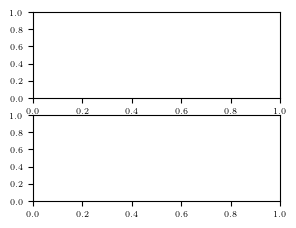

In [2]:
inches_per_dot = 1/72.27
cm2inch = 1/2.54 # inch per cm
columnwidth = 230.46733 * inches_per_dot
# columnwidth=columnwidth*0.9




left_margin = 1. * cm2inch # cm
right_margin = 1.*cm2inch  # cm
figure_width = columnwidth # cm
figure_height = columnwidth/1.2 # cm
top_margin = 1.*cm2inch    # cm
bottom_margin = 1.2*cm2inch # cm

# box_width = left_margin + figure_width + right_margin   # cm
# box_height = top_margin + figure_height + bottom_margin # cm
box_width = columnwidth
box_height = columnwidth/1.3

fs = 6

plt.rcParams.update({'font.size': fs, "text.usetex" : True})

fig, ax = plt.subplots(nrows=2,figsize=(box_width,box_height))

for err, h in zip(errors[::2],Hs[::2]):
    ax[0].semilogy(N_ths,err,'.-', label=f'$h_\\mathrm{{max}} = {h: .1e}$')



#fig.suptitle(f'Mode t={t}, $\\kappa={kappa_e}$, $H = {H:.0f}$,\n $R = 4\\lambda$, $M={N_modes}$ modes for de NtD map')

ax[0].set_xlabel('$N_p$')
#ax[0].set_ylabel('$\\frac{\\left\\Vert u - u_h\\right\\Vert_2^2} {\\left\\Vert u \\right\\Vert_2^2}\\%$')
ax[0].yaxis.set_major_locator(mticker.LogLocator(numticks=5))
ax[0].yaxis.set_minor_locator(mticker.LogLocator(numticks=5, subs="auto"))
ax[0].set_xticks(range(3,17,2))
ax[0].grid(True,which="major",ls='--')
ax[0].legend(loc="lower left")


for err, N_th in zip(errors.transpose()[::2],N_ths[::2]):
    ax[1].loglog(kappa_e*Hs,err,'.-', label=f'$N_P = {N_th}$')

ax[1].set_xlabel('$\\kappa h$')
#ax[1].set_ylabel('$\\frac{\\left\\Vert u - u_h\\right\\Vert_2^2} {\\left\\Vert u \\right\\Vert_2^2}\\%$')
ax[1].legend(loc="lower right")
ax[1].yaxis.set_major_locator(mticker.LogLocator(numticks=5))
ax[1].yaxis.set_minor_locator(mticker.LogLocator(numticks=5, subs="auto"))
ax[1].xaxis.set_major_locator(mticker.LogLocator(numticks=999))
ax[1].xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))

plt.grid(True,which="major",ls='--')




# fig.subplots_adjust(left   = left_margin / box_width,
#                     bottom = bottom_margin / box_height,
#                     right  = 1. - right_margin / box_width,
#                     top    = 1. - top_margin   / box_height)

fig.subplots_adjust(hspace=0.5)
plt.subplots_adjust(bottom=0.15)
plt.savefig('1st_mode_convergence.pdf')

working on refinement: N=1
h_max=np.float64(0.43120122022915)
Initial refinement:
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=3
h_max=np.float64(0.4471238771156382)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=5
h_max=np.float64(0.2931773731683268)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=7
h_max=np.float64(0.2019898707748881)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=9
h_max=np.float64(0.16003719324745588)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=11
h_max=np.float64(0.1296232343373048)
N_theta=3...
N_theta=5...
N_theta=7...
N_theta=9...
N_theta=11...
N_theta=13...
N_theta=15...
working on refinement: N=13
h_ma

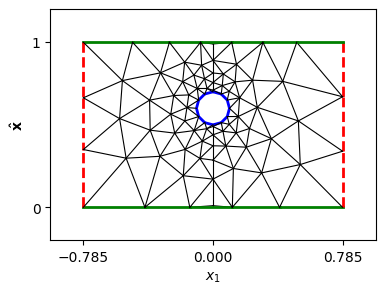

In [2]:
refinements = range(1,15,2)
N_ths = range(3,17,2)


N_ref = len(refinements)
N_N_th = len(N_ths)

hs = np.zeros((N_ref), dtype=np.float64)
Hs = np.zeros((N_ref), dtype=np.float64)

conds = np.zeros((N_ref,N_N_th), dtype=np.float64)
errors = np.zeros((N_ref,N_N_th), dtype=np.float64)

factor = 8/8

kappa_e = factor*8.
lambda_e = 2*np.pi/kappa_e
R = factor*lambda_e
H = 1.


c = (0,0.6*H)
r = 0.1*H


Ny = 100
Nx = int(R/H*Ny)

x = np.linspace(-R,R,Nx)
y = np.linspace(0,H,Ny)
X, Y = np.meshgrid(x,y)

t = 3
#u_exact = np.reshape( Mode( kappa_e, H, np.stack([X.ravel(),Y.ravel()], axis=1), t=t), (Ny,Nx))
u_exact = np.reshape(GreenFunctionModes(kappa_e, H, np.stack([X.ravel(),Y.ravel()], axis=1), c[0], c[1], M = 800), (Ny,Nx))

for (i,N) in enumerate(refinements):
    print(f"working on refinement: {N=}")
    h = H/(N)
    hs[i] = h
   
    Domain = Waveguide(R=R,H=H)
    Domain.add_scatterer(scatterer_shape=ScattererShape.CIRCLE, scatterer_type=ScattererType.SOUND_SOFT, params=(c,r, True))
    Domain.generate_mesh(h_max=h)

    side_ls = np.array([E.l for E in Domain.Edges])
    h_max = np.max(side_ls)
    Hs[i] = h_max
    print(f'{h_max=}')

    if i == 0:
        print('Initial refinement:')
        Domain.plot_mesh()

    for (j,Nth) in enumerate(N_ths):
        print(f"N_theta={Nth}...")
        th_0 = np.e/np.pi # no correct direction in the basis
        V = TrefftzSpace(Domain, Nth, {"Omega_i" : kappa_e , "Omega_e" : kappa_e}, th_0 )
        N_modes = 15 #Number of modes for the DtN map
        # "UWVF" parameters
        a = 0.5
        b = 0.5
        d_1 = 0.5
        d_2 = 0.5

        #A = AssembleMatrix(V, Domain.Edges, H, Np=N_modes, a=a, b=b, d_1=d_1, d_2=d_2)
        A = Assemble_blockMatrix(V, Domain.Edges, th_0, H, k=kappa_e, N_p=Nth, a=a, b=b, d_1=d_1, d_2=d_2, N_DtN=N_modes)

 
        # _, _, conds[i,j] = cond(A)
        #B = AssembleRHS(V, Domain.Edges, kappa_e, Domain.H, d_2=d_2, t=t )
        B = AssembleGreenRHS(V, Domain.Edges, kappa_e, H, a, c[0], c[1],  M = N_modes)
        A = A.tocsc()
        
        DOFs = solve(A,B)
        f = TrefftzFunction(V,DOFs)

        u_Trefft =  np.reshape([ f(x_, y_) for x_, y_ in zip( X.ravel(), Y.ravel()) ], [Ny,Nx])
        errors[i,j] = Domain.L2_norm(X,Y,u_exact-u_Trefft)/Domain.L2_norm(X,Y,u_exact)


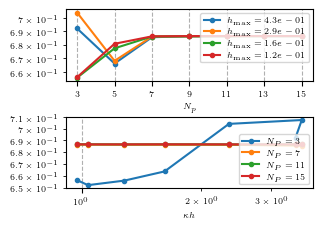

In [3]:
inches_per_dot = 1/72.27
cm2inch = 1/2.54 # inch per cm
columnwidth = 230.46733 * inches_per_dot
# columnwidth=columnwidth*0.9




left_margin = 1. * cm2inch # cm
right_margin = 1.*cm2inch  # cm
figure_width = columnwidth # cm
figure_height = columnwidth/1.2 # cm
top_margin = 1.*cm2inch    # cm
bottom_margin = 1.2*cm2inch # cm

# box_width = left_margin + figure_width + right_margin   # cm
# box_height = top_margin + figure_height + bottom_margin # cm
box_width = columnwidth
box_height = columnwidth/1.3

fs = 6

plt.rcParams.update({'font.size': fs, "text.usetex" : True})

fig, ax = plt.subplots(nrows=2,figsize=(box_width,box_height))

for err, h in zip(errors[::2],Hs[::2]):
    ax[0].semilogy(N_ths,err,'.-', label=f'$h_\\mathrm{{max}} = {h: .1e}$')



#fig.suptitle(f'Mode t={t}, $\\kappa={kappa_e}$, $H = {H:.0f}$,\n $R = 4\\lambda$, $M={N_modes}$ modes for de NtD map')

ax[0].set_xlabel('$N_p$')
#ax[0].set_ylabel('$\\frac{\\left\\Vert u - u_h\\right\\Vert_2^2} {\\left\\Vert u \\right\\Vert_2^2}\\%$')
ax[0].yaxis.set_major_locator(mticker.LogLocator(numticks=5))
ax[0].yaxis.set_minor_locator(mticker.LogLocator(numticks=5, subs="auto"))
ax[0].set_xticks(range(3,17,2))
ax[0].grid(True,which="major",ls='--')
ax[0].legend(loc="upper right")


for err, N_th in zip(errors.transpose()[::2],N_ths[::2]):
    ax[1].loglog(kappa_e*Hs,err,'.-', label=f'$N_P = {N_th}$')

ax[1].set_xlabel('$\\kappa h$')
#ax[1].set_ylabel('$\\frac{\\left\\Vert u - u_h\\right\\Vert_2^2} {\\left\\Vert u \\right\\Vert_2^2}\\%$')
ax[1].legend(loc="lower right")
ax[1].yaxis.set_major_locator(mticker.LogLocator(numticks=5))
ax[1].yaxis.set_minor_locator(mticker.LogLocator(numticks=5, subs="auto"))
ax[1].xaxis.set_major_locator(mticker.LogLocator(numticks=999))
ax[1].xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))

plt.grid(True,which="major",ls='--')




# fig.subplots_adjust(left   = left_margin / box_width,
#                     bottom = bottom_margin / box_height,
#                     right  = 1. - right_margin / box_width,
#                     top    = 1. - top_margin   / box_height)

fig.subplots_adjust(hspace=0.5)
plt.subplots_adjust(bottom=0.15)
plt.savefig('Green_scatterer_convergence.pdf')

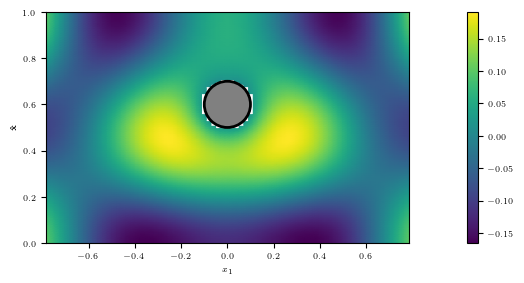

In [4]:
Domain.plot_field(X=X,Y=Y,Z=np.real(u_Trefft))

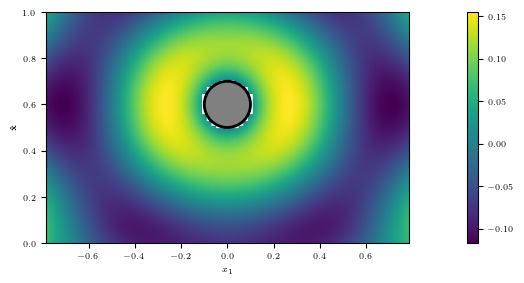

In [5]:
Domain.plot_field(X=X,Y=Y,Z=np.real(u_exact))

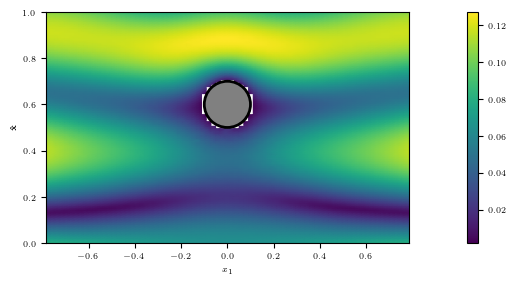

In [6]:
Domain.plot_field(X=X,Y=Y,Z=np.abs(u_exact-u_Trefft))